In [2]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

In [3]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot.h5ad')

In [4]:
adata_b = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_b_annotation.h5ad')

In [5]:
adata.obs['annot_final_new'] = pd.concat([adata[~adata.obs['annot_final'].isin(['B'])].obs['annot_final'],
                                   adata_b.obs['annot_3rd']])

In [6]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata.h5ad')

In [7]:
adata = adata[~adata.obs['normal'].isin(['AN','DN'])]
adata_b = adata_b[~adata_b.obs['normal'].isin(['AN','DN'])]

In [8]:
temp = adata_t.obs[['sample_x','progression']].drop_duplicates()
temp.index = temp['sample_x']
progression_dict = temp['progression'].to_dict()

In [9]:
adata.obs['progression'] = adata.obs['patient'].map(
    progression_dict)

/tmp/ipykernel_6870/1323683419.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['progression'] = adata.obs['patient'].map(


# Proportion of B cells

In [9]:
all_counts = adata_b.obs[['annot_3rd','sample']].value_counts().reset_index().pivot(
    columns='annot_3rd',index='sample',values=0).fillna(0)
all_props = all_counts.div(all_counts.sum(axis=1),axis=0)
all_props['Progression'] = all_props.index.map(progression_dict).astype(str)
all_props = all_props.sort_values('Progression')
all_props['Timepoint'] = [i.split('_')[1] for i in all_props.index]
all_props['Progression Timepoint'] = all_props['Progression'].astype(str) + ' ' + all_props['Timepoint'].astype(str)

In [10]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Activated B Cell'])

RanksumsResult(statistic=-0.0902893898143269, pvalue=0.9280572514152126)

In [11]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'])

RanksumsResult(statistic=0.9011289459621018, pvalue=0.36751976419843213)

In [12]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Activated B Cell'])

RanksumsResult(statistic=0.7490253407188311, pvalue=0.4538419320508955)

In [13]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'])

RanksumsResult(statistic=0.3185531179686398, pvalue=0.7500654090411816)

In [14]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Activated B Cell'])

RanksumsResult(statistic=0.24976359332774037, pvalue=0.8027701758806185)

In [15]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'])

RanksumsResult(statistic=0.09622504486493763, pvalue=0.9233418401809065)

In [16]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Activated B Cell'])

RanksumsResult(statistic=-0.06666666666666667, pvalue=0.9468470713992698)

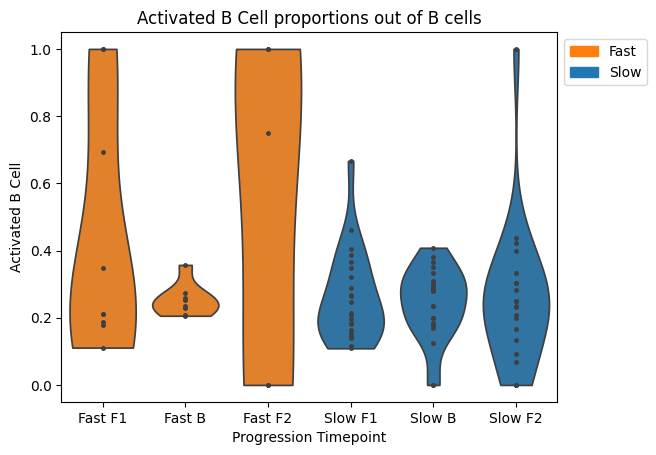

In [17]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Activated B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Activated B Cell proportions out of B cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [18]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Resting Memory B Cell'])

RanksumsResult(statistic=-0.22572347453581723, pvalue=0.8214164991969978)

In [19]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'])

RanksumsResult(statistic=-2.20043114711676, pvalue=0.027776319993960342)

In [20]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Resting Memory B Cell'])

RanksumsResult(statistic=-1.6853070166173698, pvalue=0.09192935268342341)

In [21]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'])

RanksumsResult(statistic=0.6590754164868409, pvalue=0.5098473410934687)

In [22]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Resting Memory B Cell'])

RanksumsResult(statistic=-0.32923382756838504, pvalue=0.7419789561805046)

In [23]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'])

RanksumsResult(statistic=1.6358257627039396, pvalue=0.10187605853790069)

In [24]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Resting Memory B Cell'])

RanksumsResult(statistic=0.4666666666666667, pvalue=0.6407383818025407)

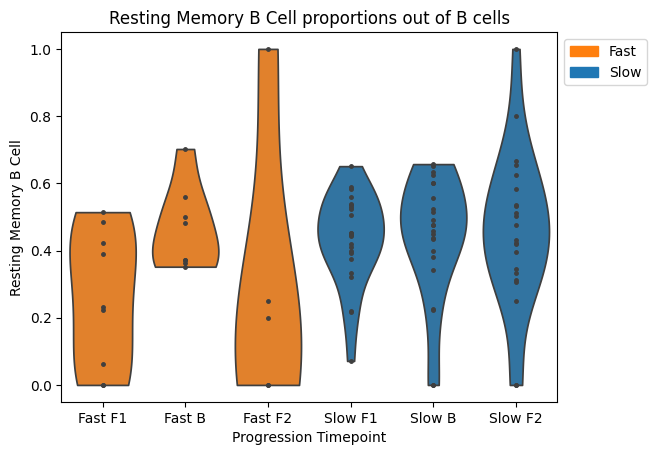

In [25]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Resting Memory B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Resting Memory B Cell proportions out of B cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [26]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Naive B Cell'])

RanksumsResult(statistic=1.060900330318341, pvalue=0.2887351991565632)

In [27]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'])

RanksumsResult(statistic=-0.20956487115397715, pvalue=0.8340072995369109)

In [28]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Naive B Cell'])

RanksumsResult(statistic=-1.2483755678647184, pvalue=0.21189355203127813)

In [29]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'])

RanksumsResult(statistic=-0.5602141040138148, pvalue=0.5753334079092218)

In [30]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Naive B Cell'])

RanksumsResult(statistic=1.5780517942070869, pvalue=0.11455371140183743)

In [31]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'])

RanksumsResult(statistic=0.4811252243246881, pvalue=0.6304275015358904)

In [32]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Naive B Cell'])

RanksumsResult(statistic=1.2666666666666666, pvalue=0.20527450366427158)

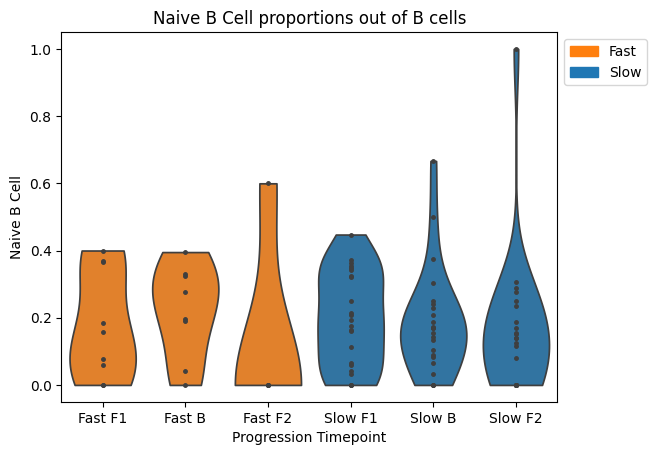

In [33]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Naive B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Naive B Cell proportions out of B cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [34]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Atypical Memory B Cell'])

RanksumsResult(statistic=-0.812604508328942, pvalue=0.41644484593045317)

In [35]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=-0.6077381263465338, pvalue=0.5433611719363407)

In [36]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=-2.340704189746347, pvalue=0.019247410298498815)

In [37]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=0.6041524651129375, pvalue=0.5457422809688558)

In [38]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=0.26111648393354675, pvalue=0.794002680192762)

In [39]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=0.3849001794597505, pvalue=0.7003113729368902)

In [40]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=1.6666666666666667, pvalue=0.0955807045456294)

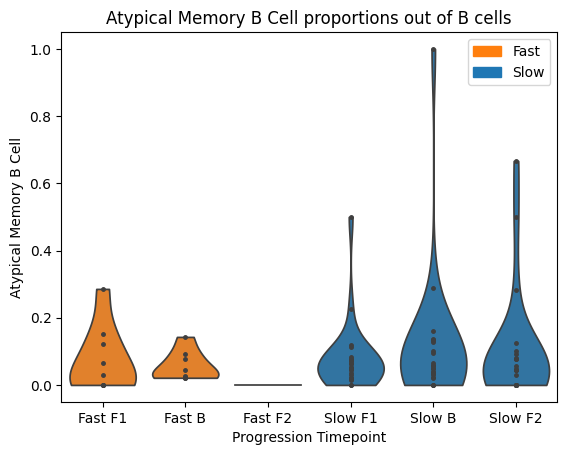

In [41]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Atypical Memory B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Atypical Memory B Cell proportions out of B cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [42]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.7674598134217786, pvalue=0.44280817767503755)

In [43]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.16765189692318172, pvalue=0.8668571411258671)

In [44]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.3120938919661796, pvalue=0.7549691683760913)

In [45]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.9446747636311387, pvalue=0.3448249448015488)

In [46]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=0.9309370296761232, pvalue=0.35188613838260596)

In [47]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.8660254037844386, pvalue=0.3864762307712327)

In [48]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=0.4666666666666667, pvalue=0.6407383818025407)

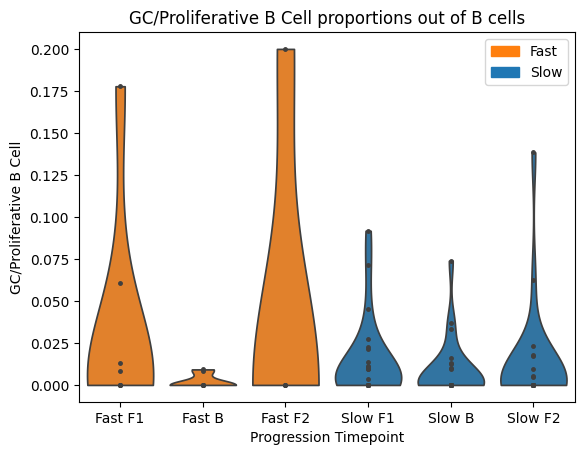

In [49]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="GC/Proliferative B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('GC/Proliferative B Cell proportions out of B cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [50]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['EIF6+ B Cell'])

RanksumsResult(statistic=0.4740192965252162, pvalue=0.6354861468772914)

In [51]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'])

RanksumsResult(statistic=0.2724343325001703, pvalue=0.7852880771471985)

In [52]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['EIF6+ B Cell'])

RanksumsResult(statistic=-1.4044225138478081, pvalue=0.1601930705853719)

In [53]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-2.207902645230917, pvalue=0.02725106041453212)

In [54]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['EIF6+ B Cell'])

RanksumsResult(statistic=1.6575220284477317, pvalue=0.09741397902174956)

In [55]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-1.058475493514314, pvalue=0.28983871760750823)

In [56]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['EIF6+ B Cell'])

RanksumsResult(statistic=1.6666666666666667, pvalue=0.0955807045456294)

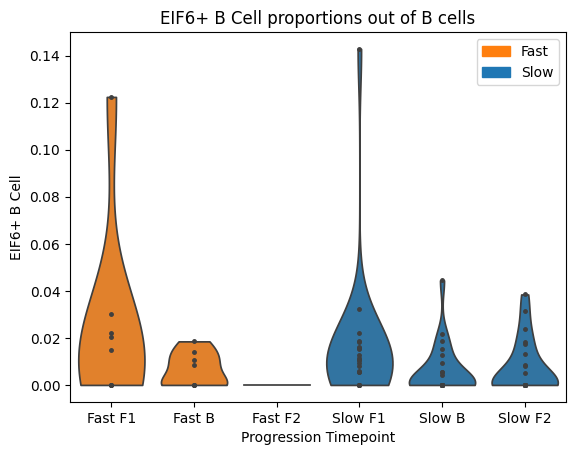

In [57]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="EIF6+ B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('EIF6+ B Cell proportions out of B cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

# As proportion of all cells

In [10]:
all_counts = adata.obs[['annot_final_new','sample']].value_counts().reset_index().pivot(
    columns='annot_final_new',index='sample',values=0).fillna(0)
all_props = all_counts.div(all_counts.sum(axis=1),axis=0)
all_props['Progression'] = all_props.index.map(progression_dict).astype(str)
all_props = all_props.sort_values('Progression')
all_props['Timepoint'] = [i.split('_')[1] for i in all_props.index]
all_props['Progression Timepoint'] = all_props['Progression'].astype(str) + ' ' + all_props['Timepoint'].astype(str)

In [11]:
adata_b.obs['annot_3rd'].unique()

['Activated B Cell', 'Resting Memory B Cell', 'Naive B Cell', 'Atypical Memory B Cell', 'GC/Proliferative B Cell', 'EIF6+ B Cell']
Categories (6, object): ['Activated B Cell', 'Atypical Memory B Cell', 'EIF6+ B Cell', 'GC/Proliferative B Cell', 'Naive B Cell', 'Resting Memory B Cell']

In [12]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Activated B Cell'])

RanksumsResult(statistic=0.7073955730226379, pvalue=0.4793206872507)

In [13]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'])

RanksumsResult(statistic=-2.42535625036333, pvalue=0.01529337103019893)

In [14]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Activated B Cell'])

RanksumsResult(statistic=-2.547510924849137, pvalue=0.01084944559435901)

In [15]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'])

RanksumsResult(statistic=-2.5671467326467288, pvalue=0.010253921182571684)

In [16]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Activated B Cell'])

RanksumsResult(statistic=2.737751869656302, pvalue=0.006186073024745249)

In [17]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'])

RanksumsResult(statistic=0.9271726499455306, pvalue=0.35383690068472917)

In [18]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Activated B Cell'])

RanksumsResult(statistic=2.5927248643506746, pvalue=0.009521891184098828)

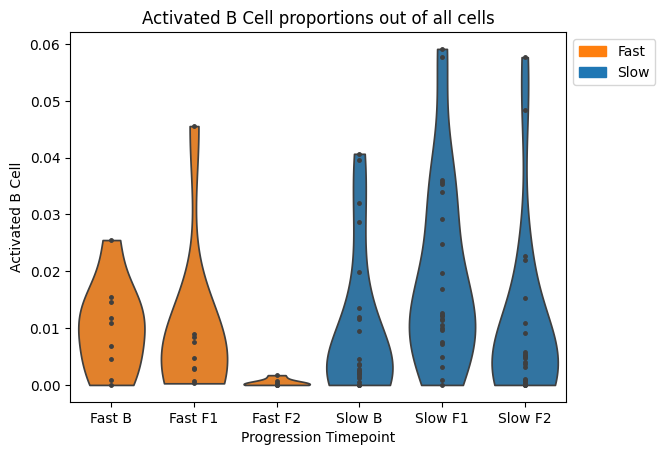

In [19]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Activated B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Activated B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [12]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Resting Memory B Cell'])

RanksumsResult(statistic=0.7073955730226379, pvalue=0.4793206872507)

In [13]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'])

RanksumsResult(statistic=-2.42535625036333, pvalue=0.01529337103019893)

In [20]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Resting Memory B Cell'])

RanksumsResult(statistic=-3.079408810257199, pvalue=0.0020741185526786674)

In [21]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'])

RanksumsResult(statistic=-2.360950207936148, pvalue=0.01822817785893125)

In [22]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Resting Memory B Cell'])

RanksumsResult(statistic=1.979097737100941, pvalue=0.047805003212387905)

In [23]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'])

RanksumsResult(statistic=1.280381278496209, pvalue=0.20041107494054256)

In [24]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Resting Memory B Cell'])

RanksumsResult(statistic=2.121320343559643, pvalue=0.033894853524689246)

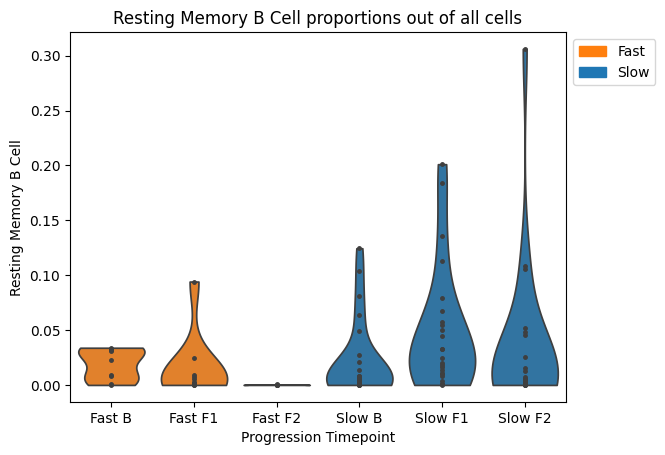

In [25]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Resting Memory B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Resting Memory B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [26]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Naive B Cell'])

RanksumsResult(statistic=0.970142500145332, pvalue=0.33197546708273684)

In [27]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'])

RanksumsResult(statistic=-1.3339459376998315, pvalue=0.18222157493333113)

In [28]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Naive B Cell'])

RanksumsResult(statistic=-2.26756466937121, pvalue=0.023355753129164488)

In [29]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'])

RanksumsResult(statistic=-2.165063509461097, pvalue=0.03038282197657749)

In [30]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Naive B Cell'])

RanksumsResult(statistic=1.781187963390847, pvalue=0.07488174934785456)

In [31]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'])

RanksumsResult(statistic=0.7505683356701914, pvalue=0.45291248342491686)

In [32]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Naive B Cell'])

RanksumsResult(statistic=2.121320343559643, pvalue=0.033894853524689246)

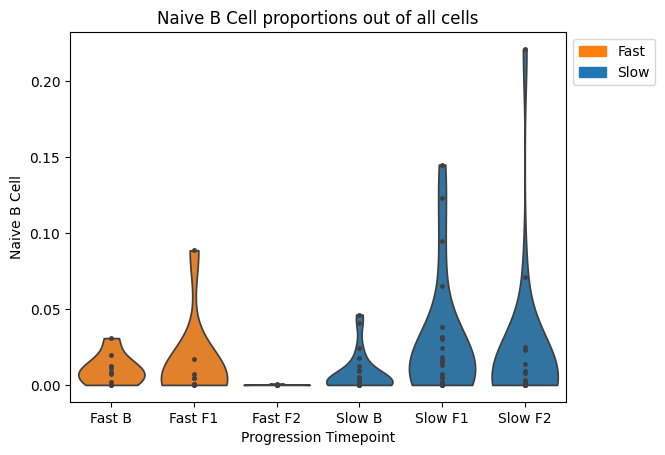

In [33]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Naive B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Naive B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [34]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Atypical Memory B Cell'])

RanksumsResult(statistic=-0.16169041669088866, pvalue=0.8715496516072889)

In [35]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=-1.5360589585634423, pvalue=0.12452392086617763)

In [36]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=-2.5195162993013445, pvalue=0.011751619941485901)

In [37]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=-2.0001062896926323, pvalue=0.0454887877497481)

In [38]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=1.7921829508191855, pvalue=0.07310366476292032)

In [39]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=-0.22075539284417398, pvalue=0.8252828980151752)

In [40]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=1.7677669529663689, pvalue=0.0770998717435417)

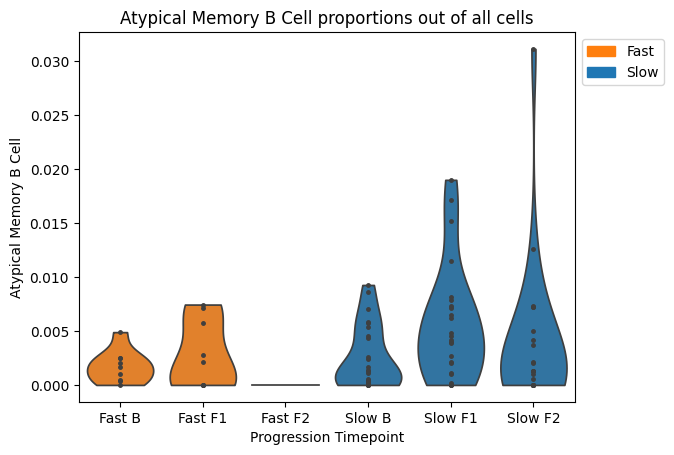

In [41]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Atypical Memory B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Atypical Memory B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [42]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.485071250072666, pvalue=0.6276258050283592)

In [43]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.40422604172722165, pvalue=0.6860465054289349)

In [44]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.9518172686249524, pvalue=0.34118966263179074)

In [45]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-1.4021363680319483, pvalue=0.16087452877075714)

In [46]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=1.1874586422605646, pvalue=0.23504676065449348)

In [47]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.9713237285143654, pvalue=0.331387096247615)

In [48]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=1.1195857368787003, pvalue=0.2628903364198475)

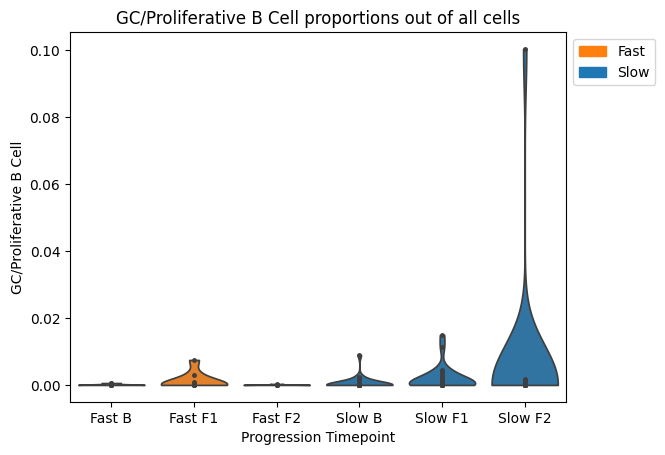

In [49]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="GC/Proliferative B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('GC/Proliferative B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [50]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['EIF6+ B Cell'])

RanksumsResult(statistic=0.18190171877724975, pvalue=0.8556598556131285)

In [51]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-0.6467616667635546, pvalue=0.5177862052646545)

In [52]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['EIF6+ B Cell'])

RanksumsResult(statistic=-1.5117097795808068, pvalue=0.13060770964153015)

In [53]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-2.7527236048862513, pvalue=0.0059101770309275825)

In [54]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['EIF6+ B Cell'])

RanksumsResult(statistic=1.9681027496726025, pvalue=0.04905621654959971)

In [55]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-0.7505683356701914, pvalue=0.45291248342491686)

In [56]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['EIF6+ B Cell'])

RanksumsResult(statistic=1.7677669529663689, pvalue=0.0770998717435417)

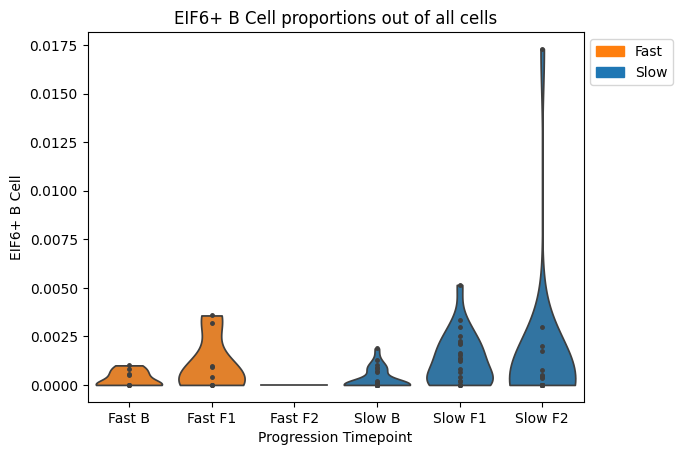

In [57]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="EIF6+ B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('EIF6+ B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

# As proportion of all immune cells

In [11]:
immune = ['Plasma',
 'Activated B Cell',
 'Resting Memory B Cell',
 'Naive B Cell',
 'Atypical Memory B Cell',
 'GC/Proliferative B Cell',
 'EIF6+ B Cell',
 'C1QC Macrophage',
 'cDC2',
 'Monocyte',
 'CD14 Monocyte',
 'Mast',
 'mregDC',
 'cDC1',
 'SPP1 Macrophage',
 'pDC',
 'Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'CD4 T naive/early memory Cell',
 'GZMK+ CD8 T progrenitor ex Cell',
 'Th17/Tc17',
 'NK',
 'gd T Cell',
 'Tc17',
 'CD8 T naive/early memory Cell',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'T naive/early memory Cell',
 'Terminal CD8 Tex Cell',
 'Tnaive Cell']

In [12]:
all_counts = adata[adata.obs['annot_final_new'].isin(immune)].obs[['annot_final_new','sample']].value_counts().reset_index().pivot(
    columns='annot_final_new',index='sample',values=0).fillna(0)
all_props = all_counts.div(all_counts.sum(axis=1),axis=0)
all_props['Progression'] = all_props.index.map(progression_dict).astype(str)
all_props = all_props.sort_values('Progression')
all_props['Timepoint'] = [i.split('_')[1] for i in all_props.index]
all_props['Progression Timepoint'] = all_props['Progression'].astype(str) + ' ' + all_props['Timepoint'].astype(str)

In [18]:
adata_b.obs['annot_3rd'].unique()

['Activated B Cell', 'Resting Memory B Cell', 'Naive B Cell', 'Atypical Memory B Cell', 'GC/Proliferative B Cell', 'EIF6+ B Cell']
Categories (6, object): ['Activated B Cell', 'Atypical Memory B Cell', 'EIF6+ B Cell', 'GC/Proliferative B Cell', 'Naive B Cell', 'Resting Memory B Cell']

In [19]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Activated B Cell'])

RanksumsResult(statistic=0.7073955730226379, pvalue=0.4793206872507)

In [20]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'])

RanksumsResult(statistic=-2.384933646190608, pvalue=0.01708220211375683)

In [21]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Activated B Cell'])

RanksumsResult(statistic=-2.547510924849137, pvalue=0.01084944559435901)

In [22]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'])

RanksumsResult(statistic=-2.6290056900599033, pvalue=0.008563492804623466)

In [23]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Activated B Cell'])

RanksumsResult(statistic=2.5948170330879003, pvalue=0.00946412853802707)

In [24]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'])

RanksumsResult(statistic=0.7505683356701914, pvalue=0.45291248342491686)

In [25]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Activated B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Activated B Cell'])

RanksumsResult(statistic=2.946278254943948, pvalue=0.003216229310127449)

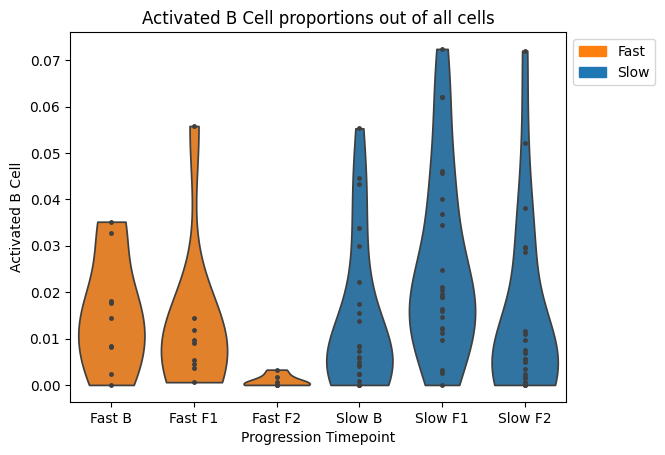

In [26]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Activated B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Activated B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [27]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Resting Memory B Cell'])

RanksumsResult(statistic=0.990353802231693, pvalue=0.32200121760451583)

In [28]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'])

RanksumsResult(statistic=-2.182820625326997, pvalue=0.02904902216194057)

In [29]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Resting Memory B Cell'])

RanksumsResult(statistic=-2.7994625547792715, pvalue=0.0051187753087051525)

In [30]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'])

RanksumsResult(statistic=-2.319710902994032, pvalue=0.020356521632181022)

In [31]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Resting Memory B Cell'])

RanksumsResult(statistic=1.902132825102571, pvalue=0.05715379208146136)

In [32]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'])

RanksumsResult(statistic=1.3686834356338786, pvalue=0.1710982503179317)

In [33]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Resting Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Resting Memory B Cell'])

RanksumsResult(statistic=1.885618083164127, pvalue=0.05934643879191985)

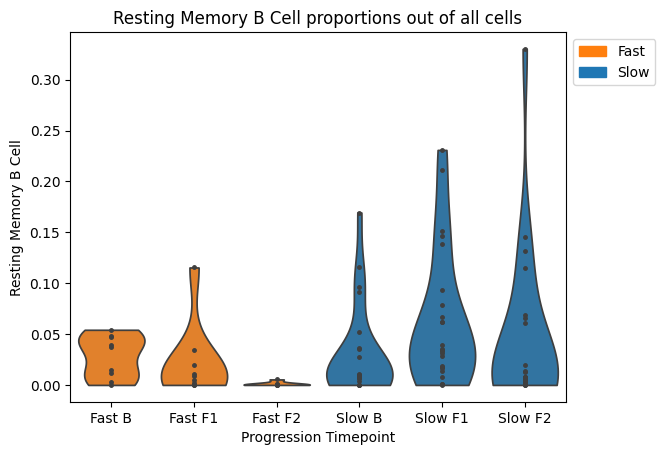

In [34]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Resting Memory B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Resting Memory B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [35]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Naive B Cell'])

RanksumsResult(statistic=0.8488746876271654, pvalue=0.3959510250893422)

In [36]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'])

RanksumsResult(statistic=-1.2531007293543872, pvalue=0.21016905065366953)

In [37]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Naive B Cell'])

RanksumsResult(statistic=-2.0995969160844536, pvalue=0.03576431429632758)

In [38]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'])

RanksumsResult(statistic=-2.0619652471058063, pvalue=0.03921104477359958)

In [39]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Naive B Cell'])

RanksumsResult(statistic=1.7372080136774928, pvalue=0.08235046093881786)

In [40]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'])

RanksumsResult(statistic=0.6622661785325219, pvalue=0.5078006482752733)

In [41]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Naive B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Naive B Cell'])

RanksumsResult(statistic=2.121320343559643, pvalue=0.033894853524689246)

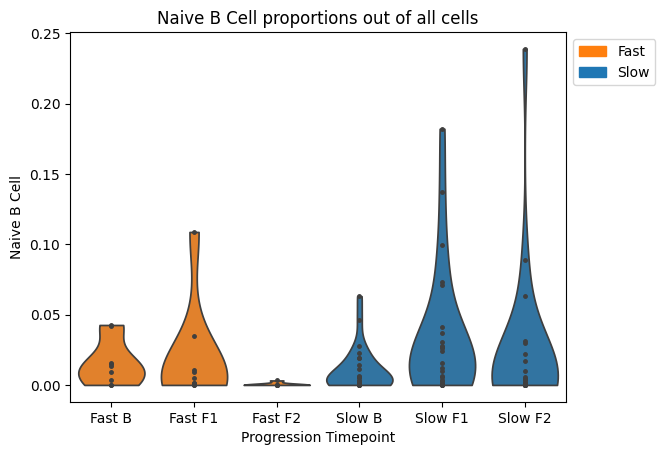

In [42]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Naive B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Naive B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [43]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Atypical Memory B Cell'])

RanksumsResult(statistic=-0.3233808333817773, pvalue=0.7464068431670373)

In [44]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=-1.3339459376998315, pvalue=0.18222157493333113)

In [45]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=-2.5195162993013445, pvalue=0.011751619941485901)

In [46]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=-2.0825848995768643, pvalue=0.037289076813638876)

In [47]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=1.3963634033989973, pvalue=0.16260508972326615)

In [48]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'])

RanksumsResult(statistic=-0.044151078568834795, pvalue=0.9647839776414971)

In [49]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Atypical Memory B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Atypical Memory B Cell'])

RanksumsResult(statistic=1.7677669529663689, pvalue=0.0770998717435417)

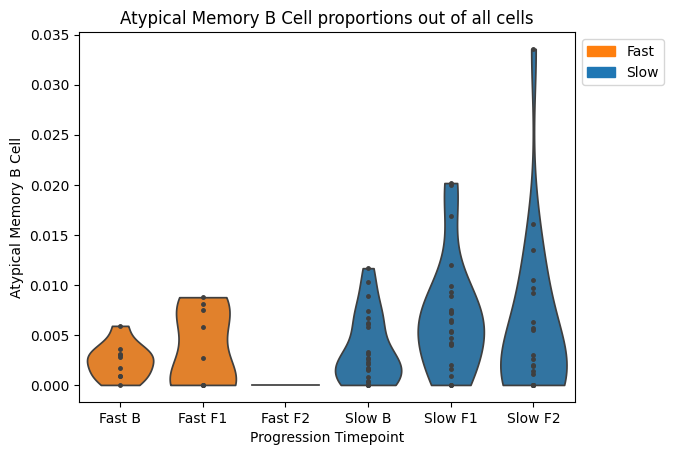

In [50]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Atypical Memory B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Atypical Memory B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [51]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.6467616667635546, pvalue=0.5177862052646545)

In [52]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.40422604172722165, pvalue=0.6860465054289349)

In [53]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.8398387664337815, pvalue=0.4009987943073907)

In [54]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-1.319657758147716, pvalue=0.18694930948365007)

In [55]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=1.055518793120502, pvalue=0.2911881190582485)

In [56]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'])

RanksumsResult(statistic=-0.8830215713766959, pvalue=0.37722461666745344)

In [57]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['GC/Proliferative B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['GC/Proliferative B Cell'])

RanksumsResult(statistic=1.0017346066809425, pvalue=0.31647178784797814)

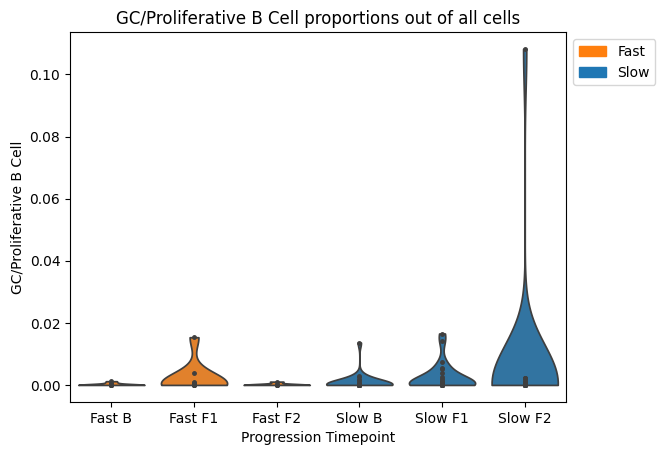

In [58]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="GC/Proliferative B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('GC/Proliferative B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))

In [59]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['EIF6+ B Cell'])

RanksumsResult(statistic=0.2627469271226941, pvalue=0.7927456445205492)

In [60]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-0.6063390625908325, pvalue=0.5442896244294022)

In [61]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['EIF6+ B Cell'])

RanksumsResult(statistic=-1.5117097795808068, pvalue=0.13060770964153015)

In [62]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-2.6083860375888452, pvalue=0.00909702974074202)

In [63]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['EIF6+ B Cell'])

RanksumsResult(statistic=1.880142850245894, pvalue=0.06008861188611991)

In [64]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'])

RanksumsResult(statistic=-0.7505683356701914, pvalue=0.45291248342491686)

In [65]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['EIF6+ B Cell'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['EIF6+ B Cell'])

RanksumsResult(statistic=1.7677669529663689, pvalue=0.0770998717435417)

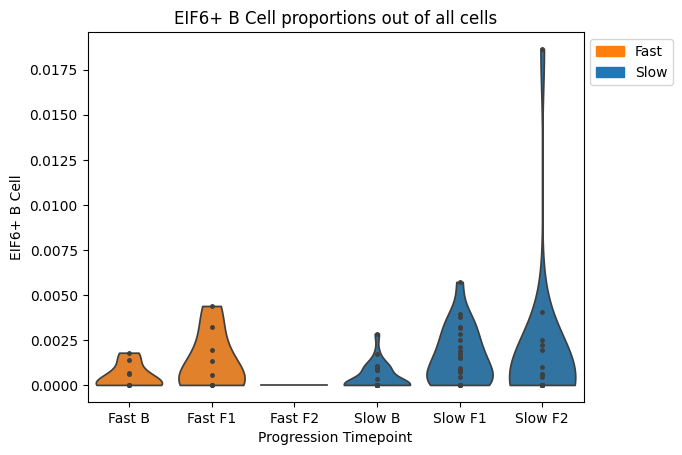

In [66]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="EIF6+ B Cell", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('EIF6+ B Cell proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))